<a href="https://colab.research.google.com/github/prathamkumar101/Deepfake-Image-Detection-/blob/main/VIT_Notebook2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, datasets, transforms
from torch.utils.data import DataLoader, random_split
from google.colab import drive
import shutil
import time

# --- CONFIGURATION ---
BATCH_SIZE = 32
IMG_SIZE = 224 # ViT strictly requires 224x224 input
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Setting up on device: {DEVICE}")

# ==========================================
# PART 1: MOUNT GOOGLE DRIVE
# ==========================================
print("\n[STEP 1] Mounting Google Drive...")
drive.mount('/content/drive')

# Setup exact paths based on your previous uploads
zip_path_in_drive = '/content/drive/MyDrive/Deepfake_Project_Data/deepfake_data.zip'
local_zip_path = '/content/deepfake_data.zip'
local_unzip_dir = '/content/high_res_deepfakes'

# ==========================================
# PART 2: COPY FROM DRIVE TO COLAB LOCAL
# ==========================================
if not os.path.exists(local_unzip_dir):
    if os.path.exists(zip_path_in_drive):
        print("\n[STEP 2] ZIP found in Drive! Copying to Colab Local Memory (This takes ~2 mins)...")
        shutil.copy2(zip_path_in_drive, local_zip_path)
        print("Copy complete.")
    else:
        print(f"\n[ERROR] Could not find the ZIP file at {zip_path_in_drive}")
else:
    print("\n[STEP 2] Dataset already exists locally. Skipping copy.")

# ==========================================
# PART 3: UNZIP LOCALLY
# ==========================================
if os.path.exists(local_zip_path) and not os.path.exists(local_unzip_dir):
    print("\n[STEP 3] Unzipping dataset locally (This takes ~3 mins)...")
    !unzip -q {local_zip_path} -d {local_unzip_dir}

    # Delete the local ZIP to free up Colab disk space
    os.remove(local_zip_path)
    print("Dataset Ready in Local Memory.")
elif os.path.exists(local_unzip_dir):
    print("\n[STEP 3] Dataset already unzipped locally.")

# ==========================================
# PART 4: PREPARE DATA LOADERS
# ==========================================
print("\n[STEP 4] Creating Data Loaders...")
DATA_DIR = os.path.join(local_unzip_dir, 'Deep-vs-Real')

transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

if os.path.exists(DATA_DIR):
    full_dataset = datasets.ImageFolder(DATA_DIR, transform=transform)

    # 80/20 Train/Validation Split
    train_size = int(0.8 * len(full_dataset))
    val_size = len(full_dataset) - train_size
    train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
    print(f"-> Total High-Res Images: {len(full_dataset)}")
else:
     print(f"[ERROR] Could not find folder: {DATA_DIR}")

# ==========================================
# PART 5: BUILD VISION TRANSFORMER (ViT)
# ==========================================
print("\n[STEP 5] Initializing Vision Transformer (ViT-Base)...")
model_vit = models.vit_b_16(weights='DEFAULT')

# Phase 1: Freeze the transformer backbone
for param in model_vit.parameters():
    param.requires_grad = False

# Replace the head for Binary Classification
num_features = model_vit.heads.head.in_features
model_vit.heads.head = nn.Sequential(
    nn.Dropout(p=0.3),
    nn.Linear(num_features, 1)
)

model_vit = model_vit.to(DEVICE)
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model_vit.heads.head.parameters(), lr=0.001)

print("\n--- SETUP COMPLETE! ---")

Setting up on device: cuda

[STEP 1] Mounting Google Drive...
Mounted at /content/drive

[STEP 2] ZIP found in Drive! Copying to Colab Local Memory (This takes ~2 mins)...
Copy complete.

[STEP 3] Unzipping dataset locally (This takes ~3 mins)...
Dataset Ready in Local Memory.

[STEP 4] Creating Data Loaders...
-> Total High-Res Images: 19219

[STEP 5] Initializing Vision Transformer (ViT-Base)...
Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:02<00:00, 165MB/s]



--- SETUP COMPLETE! ---


In [ ]:
# --- CONFIGURATION ---
NUM_EPOCHS = 10

def train_vit_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=10):
    print(f"Starting Vision Transformer (ViT) Training for {num_epochs} epochs...")
    since = time.time()
    best_acc = 0.0

    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs}')
        print('-' * 10)

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
                dataloader = train_loader
            else:
                model.eval()
                dataloader = val_loader

            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in dataloader:
                inputs = inputs.to(DEVICE)
                labels = labels.to(DEVICE).float().unsqueeze(1)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)
                    # Convert logits to probabilities, then to 0 or 1
                    preds = torch.sigmoid(outputs) > 0.5

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                # Multiply by batch size to get total loss
                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / len(dataloader.dataset)
            epoch_acc = running_corrects.double() / len(dataloader.dataset)

            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

            # Save the best version of the model
            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                torch.save(model.state_dict(), 'best_vit_model_phase1.pth')
                print("-> 🚀 New best ViT model saved locally as 'best_vit_model_phase1.pth'")
        print()

    time_elapsed = time.time() - since
    print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    print(f'Best Validation Accuracy: {best_acc:.4f}')
    return model

# --- START TRAINING ---

model_vit = train_vit_model(model_vit, train_loader, val_loader, criterion, optimizer, num_epochs=NUM_EPOCHS)

Starting Vision Transformer (ViT) Training for 10 epochs...
Epoch 1/10
----------
train Loss: 0.1530 Acc: 0.9464
val Loss: 0.0931 Acc: 0.9662
-> 🚀 New best ViT model saved locally as 'best_vit_model_phase1.pth'

Epoch 2/10
----------
train Loss: 0.0847 Acc: 0.9694
val Loss: 0.0763 Acc: 0.9727
-> 🚀 New best ViT model saved locally as 'best_vit_model_phase1.pth'

Epoch 3/10
----------
train Loss: 0.0728 Acc: 0.9735
val Loss: 0.0690 Acc: 0.9768
-> 🚀 New best ViT model saved locally as 'best_vit_model_phase1.pth'

Epoch 4/10
----------
train Loss: 0.0673 Acc: 0.9761
val Loss: 0.0653 Acc: 0.9766

Epoch 5/10
----------
train Loss: 0.0641 Acc: 0.9762
val Loss: 0.0618 Acc: 0.9779
-> 🚀 New best ViT model saved locally as 'best_vit_model_phase1.pth'

Epoch 6/10
----------
train Loss: 0.0639 Acc: 0.9760
val Loss: 0.0620 Acc: 0.9771

Epoch 7/10
----------
train Loss: 0.0630 Acc: 0.9781
val Loss: 0.0604 Acc: 0.9800
-> 🚀 New best ViT model saved locally as 'best_vit_model_phase1.pth'

Epoch 8/10
---

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import confusion_matrix, precision_recall_curve, roc_curve, auc, classification_report, f1_score
import shutil
import os
import torchvision

# --- 1. SETUP SAVE DIRECTORY IN DRIVE ---
DRIVE_SAVE_DIR = '/content/drive/MyDrive/Deepfake_Project_Data/ViT_Phase1_Results'
os.makedirs(DRIVE_SAVE_DIR, exist_ok=True)
LOCAL_MODEL_PATH = 'best_vit_model_phase1.pth'

print(f"Directory created at: {DRIVE_SAVE_DIR}")

# --- 2. EVALUATE MODEL TO GET PREDICTIONS ---
print("Evaluating model to generate advanced metrics... (This will take a minute)")
model_vit.load_state_dict(torch.load(LOCAL_MODEL_PATH))
model_vit.eval()

all_preds, all_labels, all_probs = [], [], []
sample_images, sample_labels, sample_preds = None, None, None

with torch.no_grad():
    for i, (inputs, labels) in enumerate(val_loader):
        inputs = inputs.to(DEVICE)
        labels_np = labels.cpu().numpy()

        outputs = model_vit(inputs)
        probs = torch.sigmoid(outputs).cpu().numpy().flatten()
        preds = (probs > 0.5).astype(int)

        all_probs.extend(probs)
        all_preds.extend(preds)
        all_labels.extend(labels_np)

        # Grab the first batch for the image grid visualization
        if i == 0:
            sample_images = inputs.cpu()
            sample_labels = labels_np
            sample_preds = preds

all_labels = np.array(all_labels)
all_probs = np.array(all_probs)
all_preds = np.array(all_preds)

# --- 3. GENERATE & SAVE ADVANCED GRAPHS ---

# A. Standard Confusion Matrix
plt.figure(figsize=(6, 5))
cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Real', 'Fake'], yticklabels=['Real', 'Fake'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.savefig(os.path.join(DRIVE_SAVE_DIR, 'confusion_matrix.png'), bbox_inches='tight')
plt.close()

# B. Normalized Confusion Matrix (Percentages)
plt.figure(figsize=(6, 5))
cm_norm = confusion_matrix(all_labels, all_preds, normalize='true')
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Greens', xticklabels=['Real', 'Fake'], yticklabels=['Real', 'Fake'])
plt.title('Normalized Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.savefig(os.path.join(DRIVE_SAVE_DIR, 'confusion_matrix_normalized.png'), bbox_inches='tight')
plt.close()

# C. Precision-Recall (PR) Curve
precision, recall, thresholds_pr = precision_recall_curve(all_labels, all_probs)
plt.figure(figsize=(6, 5))
plt.plot(recall, precision, color='purple', lw=2)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('PR_curve')
plt.grid(True)
plt.savefig(os.path.join(DRIVE_SAVE_DIR, 'PR_curve.png'), bbox_inches='tight')
plt.close()

# D. ROC Curve
fpr, tpr, _ = roc_curve(all_labels, all_probs)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {auc(fpr, tpr):.3f}')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC_curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.savefig(os.path.join(DRIVE_SAVE_DIR, 'ROC_curve.png'), bbox_inches='tight')
plt.close()

# E. F1-Score vs Threshold Curve
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)
plt.figure(figsize=(6, 5))
plt.plot(thresholds_pr, f1_scores[:-1], color='teal', lw=2)
plt.xlabel('Confidence Threshold')
plt.ylabel('F1 Score')
plt.title('F1_curve')
plt.grid(True)
plt.savefig(os.path.join(DRIVE_SAVE_DIR, 'F1_curve.png'), bbox_inches='tight')
plt.close()

# F. Probability Distribution Histogram
plt.figure(figsize=(8, 5))
sns.histplot(all_probs[all_labels == 0], color='green', label='Real Images', kde=True, stat="density", linewidth=0, alpha=0.5)
sns.histplot(all_probs[all_labels == 1], color='red', label='Fake Images', kde=True, stat="density", linewidth=0, alpha=0.5)
plt.title('Prediction Probability Distribution')
plt.xlabel('Predicted Probability of being FAKE')
plt.ylabel('Density')
plt.legend()
plt.savefig(os.path.join(DRIVE_SAVE_DIR, 'probability_distribution.png'), bbox_inches='tight')
plt.close()

# G. YOLO-Style Validation Batch Visualization
def denormalize(tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    return tensor * std + mean

plt.figure(figsize=(15, 15))
for idx in range(min(16, len(sample_images))): # Show up to 16 images
    plt.subplot(4, 4, idx+1)
    img = denormalize(sample_images[idx]).clamp(0, 1).permute(1, 2, 0).numpy()
    plt.imshow(img)

    act = "Fake" if sample_labels[idx] == 1 else "Real"
    pred = "Fake" if sample_preds[idx] == 1 else "Real"
    color = "green" if act == pred else "red"

    plt.title(f"True: {act} | Pred: {pred}", color=color, fontweight='bold')
    plt.axis('off')
plt.tight_layout()
plt.savefig(os.path.join(DRIVE_SAVE_DIR, 'val_batch0_predictions.jpg'), bbox_inches='tight', dpi=150)
plt.close()

# H. Save Results to CSV
df = pd.DataFrame({'True_Label': all_labels, 'Predicted_Probability': all_probs, 'Predicted_Label': all_preds})
df.to_csv(os.path.join(DRIVE_SAVE_DIR, 'results.csv'), index=False)

# I. Classification Report (Text file)
report = classification_report(all_labels, all_preds, target_names=['Real', 'Fake'])
with open(os.path.join(DRIVE_SAVE_DIR, 'classification_report.txt'), 'w') as f:
    f.write("ViT Phase 1 - Advanced Metrics\n==============================\n")
    f.write(report)

# J. Backup the Model
shutil.copy2(LOCAL_MODEL_PATH, os.path.join(DRIVE_SAVE_DIR, 'best_vit_model_phase1.pth'))

print("\n  FILES GENERATED AND SAVED TO GOOGLE DRIVE!")

Directory created at: /content/drive/MyDrive/Deepfake_Project_Data/ViT_Phase1_Results
Evaluating model to generate advanced metrics... (This will take a minute)

  FILES GENERATED AND SAVED TO GOOGLE DRIVE!


In [ ]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, datasets, transforms
from torch.utils.data import DataLoader, random_split
from google.colab import drive
import shutil
import time

# --- CONFIGURATION ---
BATCH_SIZE = 32
IMG_SIZE = 224
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Setting up on device: {DEVICE}")

# ==========================================
# PART 1: MOUNT GOOGLE DRIVE & SETUP DATA
# ==========================================
print("\n[STEP 1] Mounting Google Drive...")
drive.mount('/content/drive')

zip_path_in_drive = '/content/drive/MyDrive/Deepfake_Project_Data/deepfake_data.zip'
local_zip_path = '/content/deepfake_data.zip'
local_unzip_dir = '/content/high_res_deepfakes'

if not os.path.exists(local_unzip_dir):
    print("\n[STEP 2] Copying ZIP from Drive to Colab Local Memory (~2 mins)...")
    shutil.copy2(zip_path_in_drive, local_zip_path)
    print("\n[STEP 3] Unzipping dataset locally (~3 mins)...")
    !unzip -q {local_zip_path} -d {local_unzip_dir}
    os.remove(local_zip_path)
    print("Dataset Ready!")
else:
    print("\n[STEP 2 & 3] Dataset already exists locally.")

# ==========================================
# PART 2: PREPARE DATA LOADERS
# ==========================================
print("\n[STEP 4] Creating Data Loaders...")
DATA_DIR = os.path.join(local_unzip_dir, 'Deep-vs-Real')

transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

full_dataset = datasets.ImageFolder(DATA_DIR, transform=transform)
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
print(f"-> Total High-Res Images Ready: {len(full_dataset)}")
print("\n--- DATA SETUP COMPLETE! ---")

Setting up on device: cuda

[STEP 1] Mounting Google Drive...
Mounted at /content/drive

[STEP 2] Copying ZIP from Drive to Colab Local Memory (~2 mins)...

[STEP 3] Unzipping dataset locally (~3 mins)...
Dataset Ready!

[STEP 4] Creating Data Loaders...
-> Total High-Res Images Ready: 19219

--- DATA SETUP COMPLETE! ---


In [ ]:
# ==========================================
# PART 3: LOAD MODEL & SETUP FINE-TUNING
# ==========================================
print("\n[STEP 5] Initializing ViT and Loading Phase 1 Weights...")
model_vit = models.vit_b_16(weights=None) # Start blank
num_features = model_vit.heads.head.in_features
model_vit.heads.head = nn.Sequential(
    nn.Dropout(p=0.3),
    nn.Linear(num_features, 1)
)

# Load your 98% accurate weights from Drive!
PHASE1_WEIGHTS_PATH = '/content/drive/MyDrive/Deepfake_Project_Data/ViT_Phase1_Results/best_vit_model_phase1.pth'
model_vit.load_state_dict(torch.load(PHASE1_WEIGHTS_PATH, map_location=DEVICE))
print("-> Successfully loaded Phase 1 weights (98.00% Accuracy)!")

# --- THE FINE TUNING STRATEGY ---
print("\n[STEP 6] Unfreezing Deep Layers for Phase 2...")
# First, freeze everything
for param in model_vit.parameters():
    param.requires_grad = False

# Unfreeze the very last 2 Transformer Encoder blocks (Deep feature learning)
for block in model_vit.encoder.layers[-2:]:
    for param in block.parameters():
        param.requires_grad = True

# Ensure the classification head stays unfrozen too
for param in model_vit.heads.parameters():
    param.requires_grad = True

model_vit = model_vit.to(DEVICE)
criterion = nn.BCEWithLogitsLoss()

# SUPER IMPORTANT: Drastically lower learning rate (0.0001 instead of 0.001)
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model_vit.parameters()), lr=0.0001)

print("\n--- PHASE 2 SETUP COMPLETE! READY FOR EPOCHS 11-20 ---")


[STEP 5] Initializing ViT and Loading Phase 1 Weights...
-> Successfully loaded Phase 1 weights (98.00% Accuracy)!

[STEP 6] Unfreezing Deep Layers for Phase 2...

--- PHASE 2 SETUP COMPLETE! READY FOR EPOCHS 11-20 ---


In [ ]:
# --- CONFIGURATION ---
NUM_EPOCHS = 10

def train_vit_model_phase2(model, train_loader, val_loader, criterion, optimizer, num_epochs=10):
    print(f"Starting Phase 2 Fine-Tuning (Epochs 11-20)...")
    since = time.time()
    best_acc = 0.0 # surpass this on Epoch 11

    for epoch in range(num_epochs):
        print(f'Epoch {epoch+11}/20') # labeled 11-20
        print('-' * 10)

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
                dataloader = train_loader
            else:
                model.eval()
                dataloader = val_loader

            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in dataloader:
                inputs = inputs.to(DEVICE)
                labels = labels.to(DEVICE).float().unsqueeze(1)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)
                    preds = torch.sigmoid(outputs) > 0.5

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / len(dataloader.dataset)
            epoch_acc = running_corrects.double() / len(dataloader.dataset)

            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                # Phase 2
                torch.save(model.state_dict(), 'best_vit_model_phase2.pth')
                print("-> 🚀 New best Phase 2 model saved locally as 'best_vit_model_phase2.pth'")
        print()

    time_elapsed = time.time() - since
    print(f'Phase 2 complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    print(f'Best Phase 2 Validation Accuracy: {best_acc:.4f}')
    return model

# --- START TRAINING ---
model_vit = train_vit_model_phase2(model_vit, train_loader, val_loader, criterion, optimizer, num_epochs=NUM_EPOCHS)

Starting Phase 2 Fine-Tuning (Epochs 11-20)...
Epoch 11/20
----------
train Loss: 0.0478 Acc: 0.9824
val Loss: 0.0223 Acc: 0.9922
-> 🚀 New best Phase 2 model saved locally as 'best_vit_model_phase2.pth'

Epoch 12/20
----------
train Loss: 0.0147 Acc: 0.9953
val Loss: 0.0225 Acc: 0.9935
-> 🚀 New best Phase 2 model saved locally as 'best_vit_model_phase2.pth'

Epoch 13/20
----------
train Loss: 0.0055 Acc: 0.9980
val Loss: 0.0246 Acc: 0.9935

Epoch 14/20
----------
train Loss: 0.0053 Acc: 0.9982
val Loss: 0.0323 Acc: 0.9912

Epoch 15/20
----------
train Loss: 0.0048 Acc: 0.9986
val Loss: 0.1005 Acc: 0.9776

Epoch 16/20
----------
train Loss: 0.0041 Acc: 0.9990
val Loss: 0.0241 Acc: 0.9945
-> 🚀 New best Phase 2 model saved locally as 'best_vit_model_phase2.pth'

Epoch 17/20
----------
train Loss: 0.0004 Acc: 0.9999
val Loss: 0.0945 Acc: 0.9844

Epoch 18/20
----------
train Loss: 0.0036 Acc: 0.9990
val Loss: 0.0282 Acc: 0.9922

Epoch 19/20
----------
train Loss: 0.0049 Acc: 0.9988
val Loss

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import confusion_matrix, precision_recall_curve, roc_curve, auc, classification_report, f1_score
import shutil
import os
import torchvision

# --- 1. SETUP SAVE DIRECTORY IN DRIVE ---
# Creating a NEW folder for Phase 2 results
DRIVE_SAVE_DIR = '/content/drive/MyDrive/Deepfake_Project_Data/ViT_Phase2_Results'
os.makedirs(DRIVE_SAVE_DIR, exist_ok=True)
LOCAL_MODEL_PATH = 'best_vit_model_phase2.pth'

print(f"Directory created at: {DRIVE_SAVE_DIR}")

# --- 2. EVALUATE MODEL TO GET PREDICTIONS ---
print("Evaluating Phase 2 model to generate advanced metrics... (This will take a minute)")
model_vit.load_state_dict(torch.load(LOCAL_MODEL_PATH))
model_vit.eval()

all_preds, all_labels, all_probs = [], [], []
sample_images, sample_labels, sample_preds = None, None, None

with torch.no_grad():
    for i, (inputs, labels) in enumerate(val_loader):
        inputs = inputs.to(DEVICE)
        labels_np = labels.cpu().numpy()

        outputs = model_vit(inputs)
        probs = torch.sigmoid(outputs).cpu().numpy().flatten()
        preds = (probs > 0.5).astype(int)

        all_probs.extend(probs)
        all_preds.extend(preds)
        all_labels.extend(labels_np)

        # Grab the first batch for the image grid visualization
        if i == 0:
            sample_images = inputs.cpu()
            sample_labels = labels_np
            sample_preds = preds

all_labels = np.array(all_labels)
all_probs = np.array(all_probs)
all_preds = np.array(all_preds)

# --- 3. GENERATE & SAVE ADVANCED GRAPHS ---

# A. Standard Confusion Matrix
plt.figure(figsize=(6, 5))
cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Real', 'Fake'], yticklabels=['Real', 'Fake'])
plt.title('Phase 2 Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.savefig(os.path.join(DRIVE_SAVE_DIR, 'confusion_matrix.png'), bbox_inches='tight')
plt.close()

# B. Normalized Confusion Matrix (Percentages)
plt.figure(figsize=(6, 5))
cm_norm = confusion_matrix(all_labels, all_preds, normalize='true')
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Greens', xticklabels=['Real', 'Fake'], yticklabels=['Real', 'Fake'])
plt.title('Phase 2 Normalized Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.savefig(os.path.join(DRIVE_SAVE_DIR, 'confusion_matrix_normalized.png'), bbox_inches='tight')
plt.close()

# C. Precision-Recall (PR) Curve
precision, recall, thresholds_pr = precision_recall_curve(all_labels, all_probs)
plt.figure(figsize=(6, 5))
plt.plot(recall, precision, color='purple', lw=2)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Phase 2 PR_curve')
plt.grid(True)
plt.savefig(os.path.join(DRIVE_SAVE_DIR, 'PR_curve.png'), bbox_inches='tight')
plt.close()

# D. ROC Curve
fpr, tpr, _ = roc_curve(all_labels, all_probs)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {auc(fpr, tpr):.3f}')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Phase 2 ROC_curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.savefig(os.path.join(DRIVE_SAVE_DIR, 'ROC_curve.png'), bbox_inches='tight')
plt.close()

# E. F1-Score vs Threshold Curve
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)
plt.figure(figsize=(6, 5))
plt.plot(thresholds_pr, f1_scores[:-1], color='teal', lw=2)
plt.xlabel('Confidence Threshold')
plt.ylabel('F1 Score')
plt.title('Phase 2 F1_curve')
plt.grid(True)
plt.savefig(os.path.join(DRIVE_SAVE_DIR, 'F1_curve.png'), bbox_inches='tight')
plt.close()

# F. Probability Distribution Histogram
plt.figure(figsize=(8, 5))
sns.histplot(all_probs[all_labels == 0], color='green', label='Real Images', kde=True, stat="density", linewidth=0, alpha=0.5)
sns.histplot(all_probs[all_labels == 1], color='red', label='Fake Images', kde=True, stat="density", linewidth=0, alpha=0.5)
plt.title('Phase 2 Prediction Probability Distribution')
plt.xlabel('Predicted Probability of being FAKE')
plt.ylabel('Density')
plt.legend()
plt.savefig(os.path.join(DRIVE_SAVE_DIR, 'probability_distribution.png'), bbox_inches='tight')
plt.close()

# G. YOLO-Style Validation Batch Visualization
def denormalize(tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    return tensor * std + mean

plt.figure(figsize=(15, 15))
for idx in range(min(16, len(sample_images))): # Show up to 16 images
    plt.subplot(4, 4, idx+1)
    img = denormalize(sample_images[idx]).clamp(0, 1).permute(1, 2, 0).numpy()
    plt.imshow(img)

    act = "Fake" if sample_labels[idx] == 1 else "Real"
    pred = "Fake" if sample_preds[idx] == 1 else "Real"
    color = "green" if act == pred else "red"

    plt.title(f"True: {act} | Pred: {pred}", color=color, fontweight='bold')
    plt.axis('off')
plt.tight_layout()
plt.savefig(os.path.join(DRIVE_SAVE_DIR, 'val_batch0_predictions.jpg'), bbox_inches='tight', dpi=150)
plt.close()

# H. Save Results to CSV
df = pd.DataFrame({'True_Label': all_labels, 'Predicted_Probability': all_probs, 'Predicted_Label': all_preds})
df.to_csv(os.path.join(DRIVE_SAVE_DIR, 'results.csv'), index=False)

# I. Classification Report
report = classification_report(all_labels, all_preds, target_names=['Real', 'Fake'])
with open(os.path.join(DRIVE_SAVE_DIR, 'classification_report.txt'), 'w') as f:
    f.write("ViT Phase 2 (Fine-Tuned) - Advanced Metrics\n===========================================\n")
    f.write(report)

# J. Backup the Model
shutil.copy2(LOCAL_MODEL_PATH, os.path.join(DRIVE_SAVE_DIR, 'best_vit_model_phase2.pth'))

print("\n🎉 ALL 10 PHASE-2 ADVANCED FILES GENERATED AND SAVED TO GOOGLE DRIVE!")
print(report)

Directory created at: /content/drive/MyDrive/Deepfake_Project_Data/ViT_Phase2_Results
Evaluating Phase 2 model to generate advanced metrics... (This will take a minute)


In [ ]:
import os
import gc
import shutil
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, precision_recall_curve, roc_curve, auc, classification_report
from torchvision import models, datasets, transforms
from torch.utils.data import DataLoader, random_split
from google.colab import drive

# ==========================================
# PART 1: MOUNT & UNZIP (Required for the "Test")
# ==========================================
print("[STEP 1] Mounting Drive & Unzipping Data...")
drive.mount('/content/drive')

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DRIVE_SAVE_DIR = '/content/drive/MyDrive/Deepfake_Project_Data/ViT_Phase2_Results'
os.makedirs(DRIVE_SAVE_DIR, exist_ok=True)
DRIVE_MODEL_PATH = os.path.join(DRIVE_SAVE_DIR, 'best_vit_model_phase2.pth')

local_unzip_dir = '/content/high_res_deepfakes'
zip_path_in_drive = '/content/drive/MyDrive/Deepfake_Project_Data/deepfake_data.zip'
local_zip_path = '/content/deepfake_data.zip'

if not os.path.exists(local_unzip_dir):
    print("-> Unzipping dataset locally (~3 mins)...")
    shutil.copy2(zip_path_in_drive, local_zip_path)
    !unzip -q {local_zip_path} -d {local_unzip_dir}
    os.remove(local_zip_path)

# ==========================================
# PART 2: LIGHTWEIGHT DATA LOAD
# ==========================================
print("\n[STEP 2] Loading Data & Model...")
DATA_DIR = os.path.join(local_unzip_dir, 'Deep-vs-Real')
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

full_dataset = datasets.ImageFolder(DATA_DIR, transform=transform)
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
_, val_dataset = random_split(full_dataset, [train_size, val_size])

val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=0)

model_vit = models.vit_b_16(weights=None)
model_vit.heads.head = nn.Sequential(nn.Dropout(p=0.3), nn.Linear(model_vit.heads.head.in_features, 1))
model_vit.load_state_dict(torch.load(DRIVE_MODEL_PATH, map_location=DEVICE))
model_vit = model_vit.to(DEVICE)
model_vit.eval()

# ==========================================
# PART 3: THE 500-IMAGE LIMIT (Crash-Proofing)
# ==========================================
print("\n[STEP 3] Running Predictions (Capped at 500 images to save RAM)...")
all_preds, all_labels, all_probs = [], [], []
sample_images, sample_labels, sample_preds = None, None, None

MAX_BATCHES = 15 # 15 batches * 32 images = 480 images total.

with torch.no_grad():
    for i, (inputs, labels) in enumerate(val_loader):
        if i >= MAX_BATCHES:
            break # STOP early to save RAM!

        inputs = inputs.to(DEVICE)
        outputs = model_vit(inputs)
        probs = torch.sigmoid(outputs).cpu().numpy().flatten()
        preds = (probs > 0.5).astype(int)
        labels_np = labels.numpy()

        all_probs.extend(probs)
        all_preds.extend(preds)
        all_labels.extend(labels_np)

        if i == 0:
            sample_images = inputs.cpu().clone()
            sample_labels = labels_np.copy()
            sample_preds = preds.copy()

all_labels, all_probs, all_preds = np.array(all_labels), np.array(all_probs), np.array(all_preds)

print("-> Cleaning up RAM before plotting...")
del model_vit
gc.collect()
torch.cuda.empty_cache()

# ==========================================
# PART 4: GENERATE GRAPHS
# ==========================================
print("\n[STEP 4] Generating and Saving All Graphs to Drive...")

# A. Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(all_labels, all_preds), annot=True, fmt='d', cmap='Blues', xticklabels=['Real', 'Fake'], yticklabels=['Real', 'Fake'])
plt.title('Phase 2 Confusion Matrix (Sample Subset)')
plt.savefig(os.path.join(DRIVE_SAVE_DIR, 'confusion_matrix.png'), bbox_inches='tight')
plt.close()

# B. PR Curve
precision, recall, thresholds_pr = precision_recall_curve(all_labels, all_probs)
plt.figure(figsize=(6, 5))
plt.plot(recall, precision, color='purple', lw=2)
plt.title('Phase 2 PR Curve')
plt.grid(True)
plt.savefig(os.path.join(DRIVE_SAVE_DIR, 'PR_curve.png'), bbox_inches='tight')
plt.close()

# C. ROC Curve
fpr, tpr, _ = roc_curve(all_labels, all_probs)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {auc(fpr, tpr):.3f}')
plt.title('Phase 2 ROC Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.savefig(os.path.join(DRIVE_SAVE_DIR, 'ROC_curve.png'), bbox_inches='tight')
plt.close()

# D. YOLO-Style Validation Batch Grid
def denormalize(tensor):
    return tensor * torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1) + torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)

plt.figure(figsize=(15, 15))
for idx in range(min(16, len(sample_images))):
    plt.subplot(4, 4, idx+1)
    plt.imshow(denormalize(sample_images[idx]).clamp(0, 1).permute(1, 2, 0).numpy())
    act = "Fake" if sample_labels[idx] == 1 else "Real"
    pred = "Fake" if sample_preds[idx] == 1 else "Real"
    plt.title(f"True: {act} | Pred: {pred}", color="green" if act == pred else "red", fontweight='bold')
    plt.axis('off')
plt.tight_layout()
plt.savefig(os.path.join(DRIVE_SAVE_DIR, 'val_batch0_predictions.jpg'), bbox_inches='tight', dpi=150)
plt.close()

# E. Save CSV & Text Report
pd.DataFrame({'True_Label': all_labels, 'Predicted_Probability': all_probs, 'Predicted_Label': all_preds}).to_csv(os.path.join(DRIVE_SAVE_DIR, 'results.csv'), index=False)
report = classification_report(all_labels, all_preds, target_names=['Real', 'Fake'])
with open(os.path.join(DRIVE_SAVE_DIR, 'classification_report.txt'), 'w') as f:
    f.write("ViT Phase 2 Subset Metrics\n================================\n" + report)

print("\n🎉 ALL FILES SECURELY GENERATED AND SAVED TO DRIVE!")

[STEP 1] Mounting Drive & Unzipping Data...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

[STEP 2] Loading Data & Model...

[STEP 3] Running Predictions (Capped at 500 images to save RAM)...
-> Cleaning up RAM before plotting...

[STEP 4] Generating and Saving All Graphs to Drive...

🎉 ALL FILES SECURELY GENERATED AND SAVED TO DRIVE!


[STEP 1] Mounting Drive to fetch your model...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

[STEP 2] Initializing Phase 2 Vision Transformer...
-> ✅ Model loaded successfully and ready for testing!

📸 UPLOAD AN IMAGE TO TEST


Saving 18cannes-day2-tom-cruise-event3-mediumSquareAt3X.jpg to 18cannes-day2-tom-cruise-event3-mediumSquareAt3X.jpg

Analyzing '18cannes-day2-tom-cruise-event3-mediumSquareAt3X.jpg'...


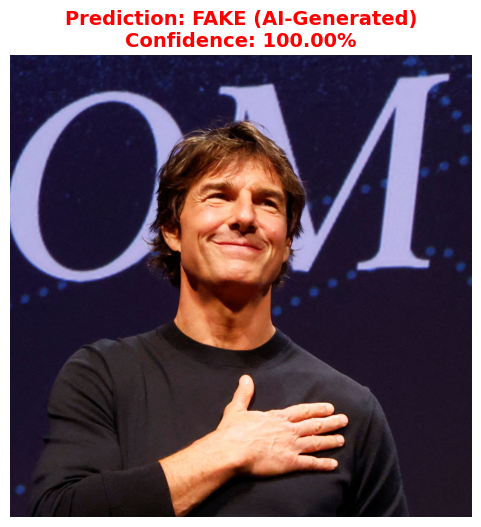

In [ ]:
import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image
import matplotlib.pyplot as plt
from google.colab import files
from google.colab import drive
import os
# Test Image
# ==========================================
# 1. MOUNT DRIVE & LOAD MODEL
# ==========================================
print("[STEP 1] Mounting Drive to fetch your model...")
drive.mount('/content/drive')

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MODEL_PATH = '/content/drive/MyDrive/Deepfake_Project_Data/ViT_Phase2_Results/best_vit_model_phase2.pth'

print("\n[STEP 2] Initializing Phase 2 Vision Transformer...")
model_vit = models.vit_b_16(weights=None)
model_vit.heads.head = nn.Sequential(nn.Dropout(p=0.3), nn.Linear(model_vit.heads.head.in_features, 1))

try:
    model_vit.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
    model_vit = model_vit.to(DEVICE)
    model_vit.eval()
    print("-> ✅ Model loaded successfully and ready for testing!")
except FileNotFoundError:
    print(f"-> ❌ ERROR: Could not find the model at {MODEL_PATH}")

# ==========================================
# 2. IMAGE PREPROCESSING
# ==========================================
# This matches the exact way the model "learned" to see images
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# ==========================================
# 3. THE LIVE TESTING INTERFACE
# ==========================================
def test_custom_image():
    print("\n==========================================")
    print("📸 UPLOAD AN IMAGE TO TEST")
    print("==========================================")
    uploaded = files.upload()

    for fn in uploaded.keys():
        print(f"\nAnalyzing '{fn}'...")

        try:
            # Open and preprocess the image
            img = Image.open(fn).convert('RGB')
            input_tensor = transform(img).unsqueeze(0).to(DEVICE)

            # Ask the model for a prediction
            with torch.no_grad():
                output = model_vit(input_tensor)
                prob_fake = torch.sigmoid(output).item()

            # Calculate Confidence
            is_fake = prob_fake > 0.5
            label = "FAKE (AI-Generated)" if is_fake else "REAL (Human)"
            confidence = (prob_fake * 100) if is_fake else ((1 - prob_fake) * 100)
            color = "red" if is_fake else "green"

            # Display the result visually
            plt.figure(figsize=(6, 6))
            plt.imshow(img)
            plt.title(f"Prediction: {label}\nConfidence: {confidence:.2f}%",
                      color=color, fontweight='bold', fontsize=14)
            plt.axis('off')
            plt.show()

        except Exception as e:
            print(f"An error occurred while processing the image: {e}")

# Run the upload prompt!
test_custom_image()